In [1]:
import os
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib import rcParams

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,  # Use LaTeX for text (mathtext if LaTeX is not installed)
    "font.family": "serif",            # Use serif fonts
    "font.serif": ["Computer Modern"], # Default LaTeX font
    "axes.labelsize": 14,              # Axis label size
    "font.size": 13,                   # General font size
    "legend.fontsize": 12,             # Legend font size
    "xtick.labelsize": 12,             # X tick label size
    "ytick.labelsize": 12,             # Y tick label size
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"  # Optional packages
})

In [3]:
# Constants & fiducial parameters
G = 4.302e-6  # kpc (km/s)^2 / Msun
V0 = 230      # km/s, characteristic circular speed
sigma = 150   # km/s, subhalo velocity dispersion (typical)
#b_max = 50.0   # kpc, maximum impact parameter

# Define grids for subhalo mass (M) and total encounters (N)
M_vals = np.logspace(4, 10, 200)   # M in Msun
N_vals = np.logspace(0, 7, 200)     # Number of subhalos (from 1 to 1e7)
M_grid, N_grid = np.meshgrid(M_vals, N_vals)

In [4]:
def get_delta(mass_grid, number_grid, m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, impact_max):

    n       = n_resonance
    m       = m_resonance
    M_grid  = mass_grid
    N_grid  = number_grid
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * (V0**2) * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_res = 4 * np.sqrt(epsilon / alpha)
    
    prefactor = (2 * G * R_res) / (sigma * impact_max)

    # b-min 
    b_min = 21*(M_grid / 1e12)**(13/30)

    # Calculate the "log-term" from the impact parameter integration (see earlier derivation)
    log_term = np.sqrt(2 * (np.log((impact_max**2 + b_min**2) / (2*b_min**2)) + (b_min**2)/(impact_max**2 + b_min**2) - (b_min**2)/(2*b_min**2)))
    
    # Then for a given subhalo mass M, the single encounter impulse is proportional to M * (prefactor * log_term)
    # i.e., Delta I_single ~ prefactor * M * log_term.
    Delta_I_single = prefactor * M_grid * log_term
    
    # With N encounters, the RMS random-walk gives:
    Delta_I_rms = np.sqrt(N_grid) * Delta_I_single
    
    # Define the "ejection criterion" difference: positive means resonance width exceeds the cumulative impulse,
    # negative means the subhalo-driven kick is stronger than the resonance confinement.
    Delta_diff = Delta_I_res - Delta_I_rms

    return Delta_diff
    

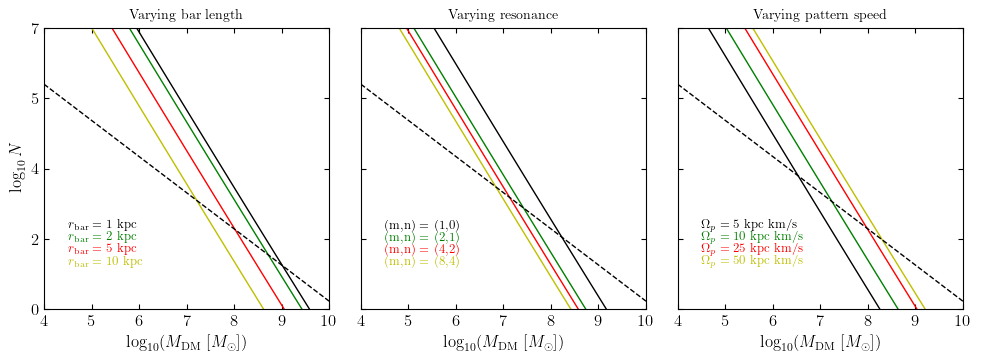

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------  helpers for log-10 labelling -----------------
log10 = lambda x: np.log10(x)

# turn a 10-based value into its base-10 logarithm for display
log_formatter = FuncFormatter(
    lambda val, _pos: f"{log10(val):.0f}" if val > 0 else "")

# --------------------------------------------------------------------

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,
                                    figsize=(10, 4),
                                    sharex=True, sharey=True)

ax1.set_rasterization_zorder(10)
ax2.set_rasterization_zorder(10)
ax3.set_rasterization_zorder(10)

ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 40, 1, 0.01, 200), 
            levels=[0], colors='k', linewidths=1)
ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 40, 2, 0.01, 200), 
            levels=[0], colors='g', linewidths=1)
ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 40, 5, 0.01, 200), 
            levels=[0], colors='r', linewidths=1)
ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 40, 10, 0.01, 200), 
            levels=[0], colors='y', linewidths=1)

ax2.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 40, 4, 0.01, 200), 
            levels=[0], colors='k', linewidths=1)
ax2.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 2, 1, 40, 4, 0.01, 200), 
            levels=[0], colors='g', linewidths=1)
ax2.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 4, 2, 40, 4, 0.01, 200), 
            levels=[0], colors='r', linewidths=1)
ax2.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 8, 4, 40, 4, 0.01, 200), 
            levels=[0], colors='y', linewidths=1)

ax3.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 5, 4, 0.01, 200), 
            levels=[0], colors='k', linewidths=1)
ax3.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 10, 4, 0.01, 200), 
            levels=[0], colors='g', linewidths=1)
ax3.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 25, 4, 0.01, 200), 
            levels=[0], colors='r', linewidths=1)
ax3.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 50, 4, 0.01, 200), 
            levels=[0], colors='y', linewidths=1)

for ax in (ax1, ax2, ax3):
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.xaxis.set_major_formatter(log_formatter)
    ax.yaxis.set_major_formatter(log_formatter)

    ax.set_xticks(np.logspace(4, 10, 7,  base=10))
    ax.set_yticks(np.logspace(0, 7, 5, base=10))

    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

ax1.set_xlabel(r"$\log_{10} (M_{\rm DM} \;[M_\odot])$", fontsize=12)
ax2.set_xlabel(r"$\log_{10} (M_{\rm DM} \;[M_\odot])$", fontsize=12)
ax3.set_xlabel(r"$\log_{10} (M_{\rm DM} \;[M_\odot])$", fontsize=12)
ax1.set_ylabel(r"$\log_{10} N$", fontsize=12)

M_lcdm = np.logspace(4, 10, 500)
N_lcdm = 100 * (M_lcdm / 1e8)**(-0.9)
for axis in (ax1, ax2, ax3):
    axis.plot(M_lcdm, N_lcdm, 'k--', lw=1)

ax1.set_title('Varying bar length', fontsize=10)
ax2.set_title('Varying resonance', fontsize=10)
ax3.set_title('Varying pattern speed', fontsize=10)

ax1.text(10**4.5, 100, r"$r_{\rm bar} = 1$ kpc", color='k', fontsize=9)
ax1.text(10**4.5, 50, r"$r_{\rm bar} = 2$ kpc", color='g', fontsize=9)
ax1.text(10**4.5, 25, r"$r_{\rm bar} = 5$ kpc", color='r', fontsize=9)
ax1.text(10**4.5, 12.5, r"$r_{\rm bar} = 10$ kpc", color='y', fontsize=9)

ax2.text(10**4.5, 100, r"(m,n) = (1,0)", color='k', fontsize=9)
ax2.text(10**4.5, 50, r"(m,n) = (2,1)", color='g', fontsize=9)
ax2.text(10**4.5, 25, r"(m,n) = (4,2)", color='r', fontsize=9)
ax2.text(10**4.5, 12.5, r"(m,n) = (8,4)", color='y', fontsize=9)

ax3.text(10**4.5, 100, r"$\Omega_p = 5$ kpc km/s", color='k', fontsize=9)
ax3.text(10**4.5, 50, r"$\Omega_p = 10$ kpc km/s", color='g', fontsize=9)
ax3.text(10**4.5, 25, r"$\Omega_p = 25$ kpc km/s", color='r', fontsize=9)
ax3.text(10**4.5, 12.5, r"$\Omega_p = 50$ kpc km/s", color='y', fontsize=9)

# optional: tighten layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

#ax1.text(10**5, 10**4.3, r'$\Lambda CDM$', rotation=-40)
#ax2.text(10**5, 10**4.3, r'$\Lambda CDM$', rotation=-40)
#ax3.text(10**5, 10**4.3, r'$\Lambda CDM$', rotation=-40)

#plt.savefig('../figures/analytic_results.pdf', dpi=400)
plt.show()


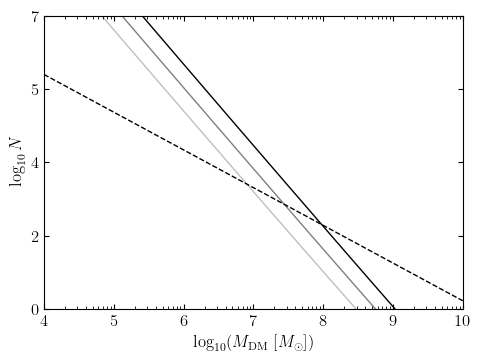

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------  helpers for log-10 labelling -----------------
log10 = lambda x: np.log10(x)

# turn a 10-based value into its base-10 logarithm for display
log_formatter = FuncFormatter(
    lambda val, _pos: f"{log10(val):.0f}" if val > 0 else "")

# --------------------------------------------------------------------

fig, ax1 = plt.subplots(1, 1, figsize=(5, 4), sharex=True, sharey=True)

ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 35, 5, 0.01, 200), 
            levels=[0], colors='k', linewidths=1)
ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 35, 5, 0.01, 100), 
            levels=[0], colors='k', linewidths=1, alpha=0.5)
ax1.contour(M_vals, N_vals, get_delta(M_grid, N_grid, 1, 0, 35, 5, 0.01, 50), 
            levels=[0], colors='k', linewidths=1, alpha=0.25)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.xaxis.set_major_formatter(log_formatter)
ax1.yaxis.set_major_formatter(log_formatter)

ax1.set_xticks(np.logspace(4, 10, 7,  base=10))
ax1.set_yticks(np.logspace(0, 7, 5, base=10))

ax1.tick_params(axis='both', which='both',
                direction='in', top=True, right=True)

ax1.set_xlabel(r"$\log_{10} (M_{\rm DM} \;[M_\odot])$", fontsize=12)
ax1.set_ylabel(r"$\log_{10} N$", fontsize=12)

M_lcdm = np.logspace(4, 10, 500)
N_lcdm = 100 * (M_lcdm / 1e8)**(-0.9)
ax1.plot(M_lcdm, N_lcdm, 'k--', lw=1)

# optional: tighten layout
plt.tight_layout(rect=[0, 0, 1, 0.95])



#plt.savefig('../figures/analytic_results.pdf', dpi=400)
plt.show()

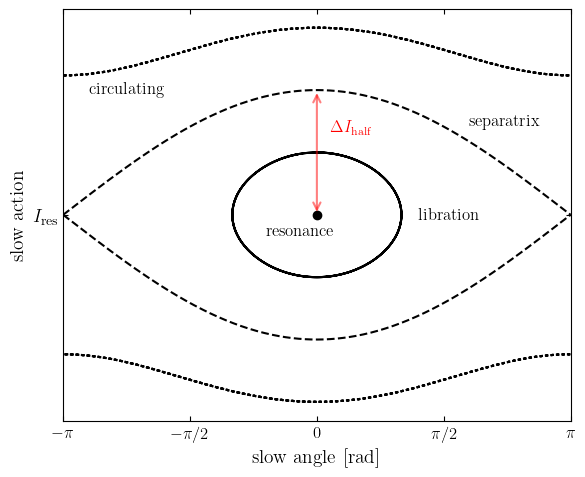

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Pendulum strength
K = 1.0  

# Equations of motion: θ'' + K sinθ = 0
def pend(t, W):
    θ, p = W
    return np.array([p, -K * np.sin(θ)])

# RK4 integrator
def rk4_step(f, t, W, dt):
    k1 = f(t, W)
    k2 = f(t + dt/2, W + dt/2 * k1)
    k3 = f(t + dt/2, W + dt/2 * k2)
    k4 = f(t + dt,   W + dt   * k3)
    return W + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# Time grid
dt = 0.01
t = np.arange(0, 20, dt)

# Initial conditions: libration vs rotation (both signs)
initial_conditions = [
    (0.0, 1.0),   # libration
    (0.0, 3.0),   # rotation, upper branch
    (0.0, -3.0),  # rotation, lower branch
]

plt.figure(figsize=(6, 5))

for θ0, p0 in initial_conditions:
    # Integrate trajectory
    W = np.array([θ0, p0])
    traj = np.zeros((len(t), 2))
    for i, ti in enumerate(t):
        traj[i] = W
        W = rk4_step(pend, ti, W, dt)
    # Normalize θ to [-π, π]
    θs = (traj[:, 0] + np.pi) % (2 * np.pi) - np.pi
    p   = traj[:, 1]

    # Find indices where jump > π (wrap discontinuity)
    dθ = np.abs(np.diff(θs))
    breaks = np.where(dθ > np.pi)[0] + 1

    # Split into continuous segments
    segments = np.split(np.arange(len(θs)), breaks)
    
    # Plot each segment

    # Plot each segment with different line styles
    linestyle = '-' if (θ0 == 0.0 and p0 == 1.0) else ':'  # Solid for libration, dotted for rotation

    for seg in segments:
        plt.plot(θs[seg] / np.pi, p[seg], linestyle=linestyle, color='k')

# Separatrix: p = ±2√K |cos(θ/2)|
θ_sep = np.linspace(-np.pi, np.pi, 400)
p_sep = 2 * np.sqrt(K) * np.abs(np.cos(θ_sep / 2))
plt.plot(θ_sep / np.pi,  p_sep, 'k--')
plt.plot(θ_sep / np.pi, -p_sep, 'k--')

# Annotate maximum separatrix width at θ = 0
I_max = np.sqrt(K)  # half-width in p; full width = 2*I_max
x0 = 0.0  # θ = 0 → θ/π = 0
# Draw double‐headed arrow across full width
plt.annotate(
    "", 
    xy=(x0/np.pi,  I_max+1), 
    xytext=(x0/np.pi, -I_max+1),
    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5, alpha=0.5)
)
# Label the arrow
plt.text(
    x0/np.pi + 0.05, 1.4, 
    r"$\Delta I_{\rm half}$", 
    color='red', 
    va='center', 
    fontsize=12
)

plt.text(
    0.4, 0, 
    r"libration", 
    color='k', 
    va='center', 
    fontsize=12
)

plt.text(
    0.6, 1.5, 
    r"separatrix", 
    color='k', 
    va='center', 
    fontsize=12
)

plt.text(
    -0.9, 2, 
    r"circulating", 
    color='k', 
    va='center', 
    fontsize=12
)

plt.text(
    -0.2, -0.25, 
    r"resonance", 
    color='k', 
    va='center', 
    fontsize=12
)

plt.scatter(0,0, color='k')

plt.xlabel(r"slow angle [rad]", fontsize=14)
plt.ylabel(r"slow action", fontsize=14)
plt.tight_layout()
plt.xlim(-1,1)

plt.yticks([0],[r'$I_{\rm res}$'], fontsize=14)
plt.xticks([-1,-0.5, 0, 0.5, 1], [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', '$\pi$'], fontsize=12)

plt.gca().tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

plt.gca().set_rasterization_zorder(10)

plt.savefig('../figures/separatrix.pdf', dpi=400)
plt.show()

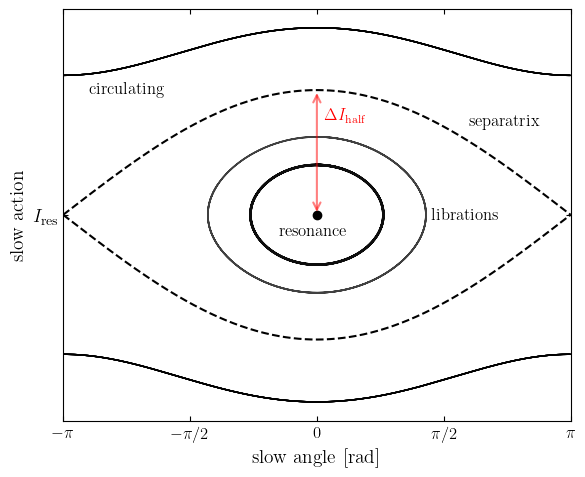

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Pendulum strength
K = 1.0  

# Equations of motion: θ'' + K sinθ = 0
def pend(t, W):
    θ, p = W
    return np.array([p, -K * np.sin(θ)])

# RK4 integrator
def rk4_step(f, t, W, dt):
    k1 = f(t, W)
    k2 = f(t + dt/2, W + dt/2 * k1)
    k3 = f(t + dt/2, W + dt/2 * k2)
    k4 = f(t + dt,   W + dt   * k3)
    return W + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# Time grid
dt = 0.01
t = np.arange(0, 20, dt)

# --- Add a few different libration examples (inside separatrix) ---
# For θ0 = 0, separatrix p is p_sep(0)=2*sqrt(K)=2, so |p0|<2 librates.
libration_ics = [
    (0.0, 0.8),   # small-amplitude libration
    (0.0, 1.25),   # medium-amplitude libration
]

# Circulating examples (outside separatrix)
rotation_ics = [
    (0.0, 3.0),    # rotation, upper branch
    (0.0, -3.0),   # rotation, lower branch
]

plt.figure(figsize=(6, 5))

# Plot librations with slightly different styles so you can tell them apart
lib_styles = [
    dict(color='k', lw=1.8, alpha=0.95),
    dict(color='k', lw=1.2, alpha=0.75),
    dict(color='k', lw=1.0, alpha=0.55),
]

def integrate_and_plot(θ0, p0, style):
    # Integrate trajectory
    W = np.array([θ0, p0], dtype=float)
    traj = np.zeros((len(t), 2))
    for i, ti in enumerate(t):
        traj[i] = W
        W = rk4_step(pend, ti, W, dt)

    # Normalize θ to [-π, π]
    θs = (traj[:, 0] + np.pi) % (2 * np.pi) - np.pi
    p  = traj[:, 1]

    # Find indices where jump > π (wrap discontinuity)
    dθ = np.abs(np.diff(θs))
    breaks = np.where(dθ > np.pi)[0] + 1

    # Split into continuous segments and plot
    segments = np.split(np.arange(len(θs)), breaks)
    for seg in segments:
        plt.plot(θs[seg] / np.pi, p[seg], linestyle='-', **style)

# Libration curves (multiple)
for (θ0, p0), st in zip(libration_ics, lib_styles):
    integrate_and_plot(θ0, p0, st)

# Rotation curves (keep them uniform black like before)
for θ0, p0 in rotation_ics:
    integrate_and_plot(θ0, p0, dict(color='k', lw=1.0, alpha=0.9))

# Separatrix: p = ±2√K |cos(θ/2)|
θ_sep = np.linspace(-np.pi, np.pi, 400)
p_sep = 2 * np.sqrt(K) * np.abs(np.cos(θ_sep / 2))
plt.plot(θ_sep / np.pi,  p_sep, 'k--')
plt.plot(θ_sep / np.pi, -p_sep, 'k--')

# --- Width arrows at a few slow angles (showing θ-dependence) ---
def p_sep_at(theta):
    return 2 * np.sqrt(K) * np.abs(np.cos(theta / 2))

def add_width_arrow(theta, x_shift=0.0, label=None, label_dy=0.15):
    x = theta / np.pi + x_shift
    ph = p_sep_at(theta)  # half-width in p at this theta
    plt.annotate(
        "",
        xy=(x,  ph),
        xytext=(x, -ph),
        arrowprops=dict(arrowstyle="<->", color="red", lw=1.5, alpha=0.5),
        zorder=5
    )
    if label is not None:
        plt.text(x + 0.03, ph + label_dy, label, color="red", fontsize=11, va="bottom")

# Existing arrow at θ=0 is fine, but here are two more examples:
#add_width_arrow(np.pi/2,  x_shift=0.02, label=r"$\Delta I_{\rm half}(\pi/2)$")
#add_width_arrow(-np.pi/2, x_shift=-0.02, label=r"$\Delta I_{\rm half}(-\pi/2)$")

# Annotate maximum separatrix width at θ = 0
I_max = np.sqrt(K)  # half-width in p; full width = 2*I_max
x0 = 0.0  # θ = 0 → θ/π = 0
plt.annotate(
    "", 
    xy=(x0/np.pi,  I_max+1), 
    xytext=(x0/np.pi, -I_max+1),
    arrowprops=dict(arrowstyle='<->', color='red', lw=1.5, alpha=0.5)
)
plt.text(
    x0/np.pi + 0.03, 1.6, 
    r"$\Delta I_{\rm half}$", 
    color='red', 
    va='center', 
    fontsize=12
)

plt.text(0.45, 0,   r"librations",   color='k', va='center', fontsize=12)
plt.text(0.6, 1.5, r"separatrix",  color='k', va='center', fontsize=12)
plt.text(-0.9, 2,  r"circulating", color='k', va='center', fontsize=12)
plt.text(-0.15, -0.25, r"resonance", color='k', va='center', fontsize=12)

plt.scatter(0, 0, color='k')

plt.xlabel(r"slow angle [rad]", fontsize=14)
plt.ylabel(r"slow action", fontsize=14)
plt.tight_layout()
plt.xlim(-1, 1)

plt.yticks([0], [r'$I_{\rm res}$'], fontsize=14)
plt.xticks([-1, -0.5, 0, 0.5, 1],
           [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', '$\pi$'],
           fontsize=12)

plt.gca().tick_params(axis='both', which='both',
                      direction='in', top=True, right=True)

plt.gca().set_rasterization_zorder(10)

#plt.savefig('../figures/separatrix.pdf', dpi=400)   # variant with two libration orbits; Fig. 1 is made by the cell above
plt.show()


In [9]:
def get_impulse(mass_grid, velocity_grid, impact_grid):

    M_grid  = mass_grid
    V_grid  = velocity_grid
    B_grid  = impact_grid

    # b-min 
    b_min = 21*(M_grid / 1e12)**(13/30)

    prefactor = (2 * G * B_grid) / (B_grid**2 + b_min**2)

    R_res = (230 / 40)
    
    # Then for a given subhalo mass M, the single encounter impulse is proportional to M * (prefactor * log_term)
    # i.e., Delta I_single ~ prefactor * M * log_term.
    Delta_I_single = prefactor * M_grid  * R_res / V_grid

    return Delta_I_single
    

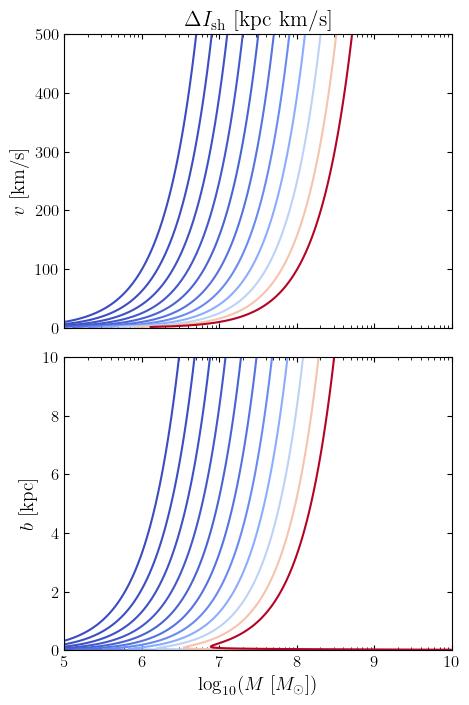

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 8), sharex=True)

levels_colors = cm.coolwarm(np.linspace(0,1000,11))

fig.subplots_adjust(hspace=0.1)

M_vals = np.logspace(5, 10, 400) 
V_vals = np.linspace(0.0, 500, 400)
M_grid, V_grid = np.meshgrid(M_vals, V_vals)
levels1 = np.logspace(-1, 1, 11)

ct1 = ax1.contour(M_grid, V_grid, get_impulse(M_grid, V_grid, 5), levels=levels1, cmap='coolwarm')
#ax1.clabel(ct1, ct1.levels[:], fontsize=10)

M_vals = np.logspace(5, 10, 400) 
B_vals = np.linspace(0.0, 10, 400)
V_grid, B_grid = np.meshgrid(M_vals, B_vals)
levels2 = np.logspace(-1, 1, 11)

ct2 = ax2.contour(M_vals, B_vals, get_impulse(M_grid, 150, B_grid), levels=levels2, cmap='coolwarm')
#ax2.clabel(ct2, ct2.levels[:], fontsize=10)

ax1.set_rasterization_zorder(10)
ax2.set_rasterization_zorder(10)

for ax in (ax1, ax2):
    ax.set_xscale('log')

    ax.xaxis.set_major_formatter(log_formatter)

    ax.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)


ax2.set_xlabel(r"$\log_{10} (M \;[M_\odot])$")

ax1.set_ylabel(r"$v$ [km/s]")
ax2.set_ylabel(r"$b$ [kpc]")

ax1.set_title(r'$\Delta I_{\rm sh}$ [kpc km/s]')

#ax1.text(10**8.2, 30, '100', c=levels_colors[0])
#ax1.text(10**9.5, 20, '1000', c=levels_colors[-1])

#ax2.text(10**8.2, 3, '100', c=levels_colors[0])
#ax2.text(10**9.65, 2, '1000', c=levels_colors[-1])

#ax1.text(10**7.5, 80, r'$b = 5$ kpc',  c='k', fontsize=12)
#ax2.text(10**7.5, 8, r'$v = 50$ km/s', c='k', fontsize=12)

#plt.savefig('../figures/single_impulse.pdf', dpi=400)
plt.show()

In [11]:
def diffusion_coefficient(mass_grid, number_grid, m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, impact_max):

    n       = n_resonance
    m       = m_resonance
    M_grid  = mass_grid
    N_grid  = number_grid
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * (V0**2) * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_res = 4 * np.sqrt(epsilon / alpha)
    
    prefactor = (2 * G * R_res) / (sigma * impact_max)

    # b-min 
    b_min = 21*(M_grid / 1e12)**(13/30)

    # Calculate the "log-term" from the impact parameter integration (see earlier derivation)
    log_term = np.sqrt(2 * (np.log((impact_max**2 + b_min**2) / (2*b_min**2)) + (b_min**2)/(impact_max**2 + b_min**2) - (b_min**2)/(2*b_min**2)))
    
    # Then for a given subhalo mass M, the single encounter impulse is proportional to M * (prefactor * log_term)
    # i.e., Delta I_single ~ prefactor * M * log_term.
    Delta_I_single = prefactor * M_grid * log_term
    
    # With N encounters, the RMS random-walk gives:
    Delta_I_rms = np.sqrt(N_grid) * Delta_I_single
    
    # Define the "ejection criterion" difference: positive means resonance width exceeds the cumulative impulse,
    # negative means the subhalo-driven kick is stronger than the resonance confinement.
    Delta_diff = Delta_I_res - Delta_I_rms

    return Delta_diff
    

In [12]:
def half_width(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, V0):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    epsilon = np.abs(f_bar * (V0**2) * (R_res**2) / (R_res + R_bar)**5) # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_res = 4 * np.sqrt(epsilon / np.abs(alpha))

    return Delta_I_res

In [13]:
V0 = 230
strength = 0.02

Op1 = 45

CR_width = half_width(1,0,Op1,4,0.02,230)
print(CR_width)

print('in order:')

print(half_width(2,-1,Op1,4,0.02,230) / CR_width)

print(half_width(1,0,Op1,4,0.02,230) / CR_width)

print(half_width(2,1,Op1,4,0.02,230) / CR_width)

print(half_width(2,2,Op1,4,0.02,230) / CR_width)

print(half_width(2,3,Op1,4,0.02,230) / CR_width)


13.564541303262367
in order:
0.3964250226474448
1.0
0.6841349658860668
0.6158746891044512
0.5493862438034669


In [14]:
def correction(u):
    a = u*230/(160**2)
    L = (1/np.tanh(a)) - 1/a
    return L/a

(0.0, 0.5)

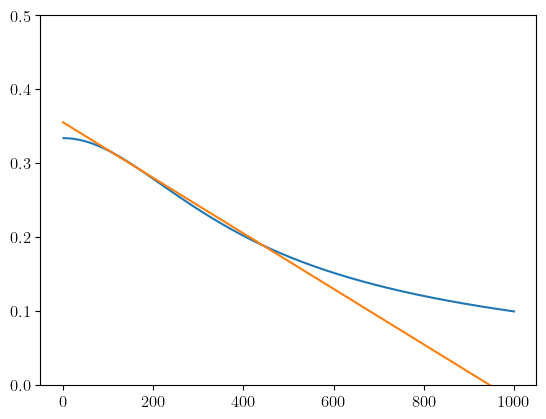

In [15]:
u_vals = np.linspace(0,1000,1000)

plt.plot(u_vals, correction(u_vals))


plt.plot(u_vals, 0.3547-0.0418*u_vals*230/(160**2))
plt.ylim(0,0.5)

In [16]:
u_vals.shape

(1000,)